<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%201/1_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to the Perceptron

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**

---

## Table of Contents
1. [Theory Recap: The Perceptron](#1.-Theory-Recap:-The-Perceptron)     
1.1 Mathematical Formulation · 1.2 The Decision Boundary · 1.3 Geometric Intuition  
2. [Setup](#2.-Setup)  
3. [Dataset: The AND Gate](#3.-Dataset:-The-AND-Gate)  
4. [The Perceptron Learning Algorithm — Step by Step](#4.-The-Perceptron-Learning-Algorithm-—-Step-by-Step)     
4.1 Step Function · 4.2 Initialise Weights · 4.3 Forward Pass · 4.4 Weight Update · 4.5 Full Training Loop · 4.6 Verification  
5. [Visualising the Decision Boundary](#5.-Visualising-the-Decision-Boundary)     
5.1 Boundary Evolution · 5.2 Manual Calculation of the AND Decision Boundary
6. [Training Error Over Epochs](#6.-Training-Error-Over-Epochs)  
7. [The XOR Problem — What the Perceptron Cannot Do](#7.-The-XOR-Problem-—-What-the-Perceptron-Cannot-Do)  
8. [Perceptron with Gradient Descent](#8.-Perceptron-with-Gradient-Descent)    
8.1 Sigmoid Activation · 8.2 Binary Cross-Entropy Loss · 8.3 What Is a Gradient? · 8.4 Gradient Computation · 8.5 Update Rule · 8.6 Manual Walkthrough · 8.7 Full Training Loop · 8.8 Decision Boundary · 8.9 Verification  
9. [Comparison: Perceptron Rule vs Gradient Descent](#9.-Comparison:-Perceptron-Rule-vs-Gradient-Descent)  
10. [Exercises](#10.-Exercises)  
11. [Summary](#11.-Summary)

---

## Session Overview
In this notebook we will:
1. **Implement the Perceptron Learning Algorithm** from scratch — including weight initialisation, forward pass, error computation, and weight updates.
2. **Visualise the decision boundary** that the perceptron learns, and manually compute it for the AND gate.
3. **Repeat the demo using Gradient Descent** with a differentiable activation function, with a clear explanation of what gradients are and why they matter.
4. **Work through exercises** that deepen your understanding.

**Prerequisites:** Basic familiarity with Python, NumPy, and the concept of a linear equation. No prior knowledge of neural networks is assumed. By the end of this notebook you should be able to explain how a single neuron learns, why it can only solve linearly separable problems, and how gradient descent extends the learning process.

---
## 1. Theory Recap: The Perceptron

The **perceptron** (Rosenblatt, 1958) is the simplest artificial neuron — the fundamental building block of all neural networks. Conceptually, it mimics a biological neuron: it receives input signals, combines them, and "fires" (outputs 1) if the combined signal exceeds a threshold. Otherwise it remains silent (outputs 0).

Despite its simplicity, the perceptron is important because **every concept we introduce here** — weighted sums, activation functions, error signals, weight updates — carries directly into deep neural networks.

### 1.1 Mathematical Formulation

Given an input vector $\mathbf{x} = [x_1, x_2, \dots, x_n]$, weights $\mathbf{w} = [w_1, w_2, \dots, w_n]$, and a bias $b$:

**Step 1 — Compute the weighted sum (pre-activation):**$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w} \cdot \mathbf{x} + b$$Each weight $w_i$ controls **how much influence** input $x_i$ has on the output. The bias $b$ shifts the decision threshold — it allows the neuron to fire even when all inputs are zero (or to suppress firing when inputs are present).

**Step 2 — Apply the step activation function:**$$\hat{y} = f(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$This converts the continuous value $z$ into a binary decision. The threshold is at $z = 0$: anything at or above zero is class 1; anything below is class 0.

**Step 3 — Compute the error:**$$e = y - \hat{y}$$where $y$ is the true label. Three cases arise:- $e = 0$: prediction is correct → no update needed.- $e = +1$: true label is 1 but we predicted 0 (a **false negative**) → we need to increase $z$.- $e = -1$: true label is 0 but we predicted 1 (a **false positive**) → we need to decrease $z$.

**Step 4 — Update the weights:**$$w_i \leftarrow w_i + \alpha \cdot e \cdot x_i$$$$b \leftarrow b + \alpha \cdot e$$where $\alpha$ is the **learning rate**, a small positive number (e.g., 0.1) that controls how aggressively the weights change at each step. Notice how the update is proportional to both the error and the input: if input $x_i$ was large when a mistake occurred, its weight gets a larger adjustment.

### 1.2 The Decision Boundary

The perceptron's equation $w_1 x_1 + w_2 x_2 + b = 0$ defines a **line** (in 2D) that separates the two classes. Points on one side produce $z \geq 0$ (class 1), and points on the other side produce $z < 0$ (class 0).
Rearranging for $x_2$:$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$
This is the standard **slope-intercept form** $x_2 = m \cdot x_1 + c$ where:
- **Slope:** $m = -w_1 / w_2$ — controls the angle of the line.
- **Intercept:** $c = -b / w_2$ — controls where the line crosses the $x_2$-axis.This is the equation we will plot as the decision boundary.

### 1.3 Geometric Intuition

Think of the weight vector $\mathbf{w} = [w_1, w_2]$ as an arrow pointing **perpendicular** to the decision boundary, towards the class-1 region. Learning moves this arrow (and the bias) so that all class-1 points lie on the positive side and all class-0 points lie on the negative side. The perceptron convergence theorem guarantees this will happen **if and only if** the data is linearly separable.

---
## 2. Setup

We begin by importing the libraries we need and setting a random seed for reproducibility. The seed ensures that every student gets the same initial weights and therefore the same training trajectory — this makes it easier to discuss results in class.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.facecolor'] = '#0F172A'
plt.rcParams['figure.facecolor'] = '#0F172A'
plt.rcParams['text.color'] = '#E2E8F0'
plt.rcParams['axes.labelcolor'] = '#E2E8F0'
plt.rcParams['xtick.color'] = '#94A3B8'
plt.rcParams['ytick.color'] = '#94A3B8'
plt.rcParams['axes.edgecolor'] = '#334155'
plt.rcParams['grid.color'] = '#334155'
plt.rcParams['grid.alpha'] = 0.5

print('Setup complete.')

Setup complete.


---
## 3. Dataset: The AND Gate

We will use the **AND logic gate** as our training data. This is a classic example because it is **linearly separable** — a single straight line can separate the positive case $(1,1) \to 1$ from the three negative cases.

| $x_1$ | $x_2$ | AND ($y$) |
|:-----:|:-----:|:---------:|
| 0     | 0     | 0         |
| 0     | 1     | 0         |
| 1     | 0     | 0         |
| 1     | 1     | 1         |

**Why AND?** It is the simplest non-trivial binary classification problem. There is only one positive example, so the perceptron must learn to "activate" only when *both* inputs are high. This makes it easy to verify results by hand and to visualise the decision boundary in 2D.

In [ ]:
# AND gate dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])  # AND labels

print('Input X:')
print(X)
print(f'\nLabels y: {y}')

Input X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Labels y: [0 0 0 1]


**Output interpretation:** The array `X` contains our four input patterns as rows, and `y` contains the corresponding AND labels. Notice that only the last row $[1, 1]$ has label 1 — the AND gate requires *both* inputs to be active.

Let's visualise the data to confirm that it is linearly separable:

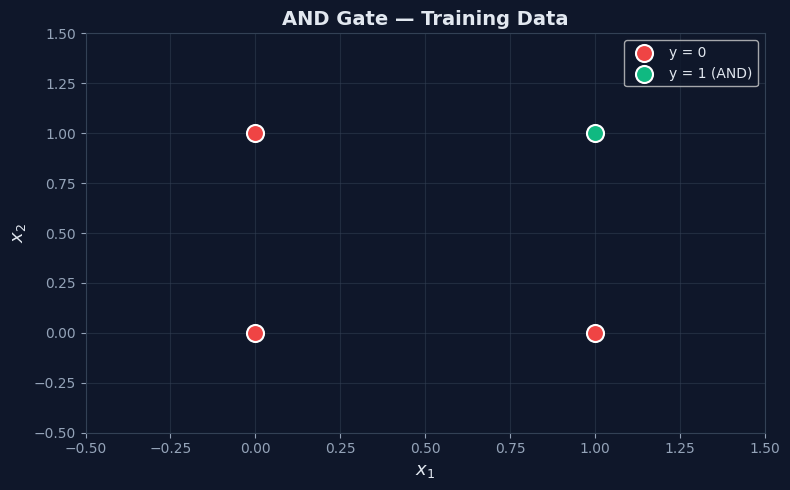

In [ ]:
fig, ax = plt.subplots()

# Plot class 0 (red) and class 1 (green)
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=150, edgecolors='white',
           linewidths=1.5, zorder=5, label='y = 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=150, edgecolors='white',
           linewidths=1.5, zorder=5, label='y = 1 (AND)')

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('AND Gate — Training Data', fontsize=14, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

**Reading the plot:** The three red points (class 0) cluster around the origin and along the axes, while the single green point (class 1) sits at $(1, 1)$. You can visually confirm linear separability: imagine drawing a diagonal line that places $(1,1)$ above it and the other three points below — such a line clearly exists. The perceptron's job is to *learn* this line automatically.

---
## 4. The Perceptron Learning Algorithm — Step by Step

We now implement the perceptron learning algorithm from scratch. We will build each component separately so you can see exactly what happens at each stage.

### 4.1 Step Function (Activation)

The step function outputs 1 if $z \geq 0$, and 0 otherwise.

Formally:$$f(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$
Note that this function is **not differentiable** at $z = 0$ (there is a sharp jump, not a smooth curve). This is why we cannot use gradient descent with it directly — we will address this limitation in Section 8.

In [ ]:
def step_function(z):
    """Heaviside step function: returns 1 if z >= 0, else 0."""
    return np.where(z >= 0, 1, 0)

# Quick test
test_z = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print(f'z values:       {test_z}')
print(f'step(z) output: {step_function(test_z)}')

z values:       [-2.  -0.5  0.   0.5  2. ]
step(z) output: [0 0 1 1 1]


**Output interpretation:** For negative values of $z$, the step function returns 0; for zero and positive values, it returns 1. The critical threshold is at $z = 0$. Notice the abrupt jump from 0 to 1 — there is no "in between". This is what makes the step function non-differentiable at that point.

### 4.2 Initialise Weights and Bias

We initialise the weights to small random values and the bias to zero. The choice of initial values matters — if we set all weights to zero, all neurons would learn the same thing (the **symmetry problem**). Small random values break this symmetry and give each weight a unique starting point.

For our 2-input perceptron:
- $w_1, w_2$: drawn from a uniform distribution in $[-0.5, 0.5]$
- $b = 0$

> **Note:** For a single perceptron, zero initialisation would technically still work because there is only one neuron. The symmetry problem becomes critical when we have multiple neurons in a layer — but it is good practice to always use random initialisation.

In [ ]:
# Initialise weights and bias
np.random.seed(42)
weights = np.random.uniform(-0.5, 0.5, size=2)
bias = 0.0

print(f'Initial weights: w1 = {weights[0]:.4f}, w2 = {weights[1]:.4f}')
print(f'Initial bias:    b  = {bias:.4f}')

Initial weights: w1 = -0.1255, w2 = 0.4507
Initial bias:    b  = 0.0000


**Output interpretation:** The two weights are small random numbers (positive or negative), and the bias starts at zero. These are the perceptron's initial "guesses" — it has not seen any data yet. The values themselves are arbitrary; what matters is that they are small and random. Training will adjust them towards values that correctly classify the AND gate.

### 4.3 Forward Pass — Manual Walkthrough

Let's manually compute the perceptron output for the first training sample $\mathbf{x} = [0, 0]$ with $y = 0$.

**Weighted sum:**$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

Since both inputs are zero, the weighted sum simplifies to just the bias: $z = 0 \cdot x_1 + 0 \cdot x_2 + b = b$.

This is an important insight: **the bias alone determines the output when all inputs are zero.**

In [ ]:
# Forward pass for the first sample
x_sample = X[0]  # [0, 0]
y_true = y[0]    # 0

z = np.dot(weights, x_sample) + bias
y_pred = step_function(z)

print(f'Input:         x = {x_sample}')
print(f'Weights:       w = [{weights[0]:.4f}, {weights[1]:.4f}]')
print(f'Bias:          b = {bias:.4f}')
print(f'Weighted sum:  z = ({weights[0]:.4f})(0) + ({weights[1]:.4f})(0) + {bias:.4f} = {z:.4f}')
print(f'Prediction:    ŷ = step({z:.4f}) = {y_pred}')
print(f'True label:    y = {y_true}')
print(f'Error:         e = y - ŷ = {y_true} - {y_pred} = {y_true - y_pred}')

Input:         x = [0 0]
Weights:       w = [-0.1255, 0.4507]
Bias:          b = 0.0000
Weighted sum:  z = (-0.1255)(0) + (0.4507)(0) + 0.0000 = 0.0000
Prediction:    ŷ = step(0.0000) = 1
True label:    y = 0
Error:         e = y - ŷ = 0 - 1 = -1


**Output interpretation:** With both inputs at zero, $z$ equals the bias (which is 0.0). Since $z = 0.0 \geq 0$, the step function outputs $\hat{y} = 1$. But the true label is $y = 0$, so the error is $e = 0 - 1 = -1$. The perceptron got this wrong and needs to update its weights.

**Why did it fail?** The initial bias of 0 sits exactly on the threshold. The step function maps $z = 0$ to 1, but the correct answer for input $(0, 0)$ is 0. The perceptron needs to learn a **negative bias** so that "no input" produces "no output".

### 4.4 Weight Update — Manual Walkthrough

Using learning rate $\alpha = 0.1$:

$$w_1 \leftarrow w_1 + \alpha \cdot e \cdot x_1 = w_1 + 0.1 \cdot (-1) \cdot 0 = w_1$$$$w_2 \leftarrow w_2 + \alpha \cdot e \cdot x_2 = w_2 + 0.1 \cdot (-1) \cdot 0 = w_2$$$$b \leftarrow b + \alpha \cdot e = 0 + 0.1 \cdot (-1) = -0.1$$

Since both inputs are 0, the weight updates involve multiplying by 0 — so the weights do not change. Only the bias changes. This makes intuitive sense: the perceptron learns that *by default* (when both inputs are 0) the output should be 0, so it shifts the bias negative to push $z$ below the threshold.

In [ ]:
alpha = 0.1  # learning rate
error = y_true - y_pred

# Weight update
weights_new = weights + alpha * error * x_sample
bias_new = bias + alpha * error

print('Weight Update Calculation:')
print(f'  w1: {weights[0]:.4f} + {alpha} × {error} × {x_sample[0]} = {weights_new[0]:.4f}')
print(f'  w2: {weights[1]:.4f} + {alpha} × {error} × {x_sample[1]} = {weights_new[1]:.4f}')
print(f'  b:  {bias:.4f} + {alpha} × {error} = {bias_new:.4f}')

# Apply the update
weights = weights_new.copy()
bias = bias_new

print(f'\nUpdated weights: w = [{weights[0]:.4f}, {weights[1]:.4f}]')
print(f'Updated bias:    b = {bias:.4f}')

Weight Update Calculation:
  w1: -0.1255 + 0.1 × -1 × 0 = -0.1255
  w2: 0.4507 + 0.1 × -1 × 0 = 0.4507
  b:  0.0000 + 0.1 × -1 = -0.1000

Updated weights: w = [-0.1255, 0.4507]
Updated bias:    b = -0.1000


**Output interpretation:** Confirm that the weights remain unchanged (multiplication by zero) and the bias shifts from 0.0 to −0.1. This small negative bias means the perceptron now defaults to "off" when both inputs are zero — exactly what the AND gate requires. The learning rate $\alpha = 0.1$ controls the step size: a larger $\alpha$ would shift the bias more aggressively.

---
### 4.5 Full Perceptron Training Loop

Now let's put it all together into a complete training loop. We iterate over all training samples for a fixed number of **epochs** (full passes through the data) and track the weights and errors at each step.

**Algorithm overview:**
1. For each epoch, loop through every training sample.
2. Compute the forward pass (weighted sum → step function → prediction).
3. If the prediction is wrong, update the weights and bias.
4. Count the total misclassifications per epoch.
5. Stop early if zero errors (convergence).

In [ ]:
def train_perceptron(X, y, alpha=0.1, epochs=20, verbose=True):
    """
    Train a perceptron using the perceptron learning rule.

    Parameters
    ----------
    X : array of shape (n_samples, n_features)
    y : array of shape (n_samples,)
    alpha : float, learning rate
    epochs : int, number of full passes through the data
    verbose : bool, print progress

    Returns
    -------
    weights, bias, history (list of dicts with epoch info)
    """
    np.random.seed(42)
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, size=n_features)
    bias = 0.0
    history = []

    for epoch in range(epochs):
        total_errors = 0

        for i in range(len(X)):
            # Forward pass
            z = np.dot(weights, X[i]) + bias
            y_pred = step_function(z)

            # Compute error
            error = y[i] - y_pred

            # Update weights and bias
            if error != 0:
                weights = weights + alpha * error * X[i]
                bias = bias + alpha * error
                total_errors += 1

        history.append({
            'epoch': epoch + 1,
            'errors': total_errors,
            'weights': weights.copy(),
            'bias': bias
        })

        if verbose and (epoch < 5 or total_errors == 0 or epoch == epochs - 1):
            print(f'Epoch {epoch+1:3d}: errors = {total_errors}, '
                  f'weights = [{weights[0]:+.4f}, {weights[1]:+.4f}], bias = {bias:+.4f}')

        # Early stopping: if no errors, we've converged
        if total_errors == 0:
            if verbose:
                print(f'\n✓ Converged after {epoch + 1} epochs!')
            break

    return weights, bias, history

# Train the perceptron on AND gate
print('Training Perceptron on AND gate (α = 0.1):\n')
weights_final, bias_final, history = train_perceptron(X, y, alpha=0.1, epochs=50)

Training Perceptron on AND gate (α = 0.1):

Epoch   1: errors = 2, weights = [-0.1255, +0.3507], bias = -0.2000
Epoch   2: errors = 2, weights = [-0.0255, +0.3507], bias = -0.2000
Epoch   3: errors = 2, weights = [+0.0745, +0.3507], bias = -0.2000
Epoch   4: errors = 1, weights = [+0.0745, +0.2507], bias = -0.3000
Epoch   5: errors = 0, weights = [+0.0745, +0.2507], bias = -0.3000

✓ Converged after 5 epochs!


**Output interpretation:** The training log shows the perceptron correcting its mistakes epoch by epoch. In the first few epochs you see multiple errors per epoch as the weights are still being adjusted. The weights and bias change after each misclassified sample. Once the perceptron finds a set of weights that correctly classifies all four AND gate inputs, the error count drops to zero and training stops. The ✓ symbol confirms convergence.

Note how few epochs are needed — this is because the AND gate is a very simple, linearly separable problem with only four data points.

### 4.6 Verifying the Learned Parameters

Let's verify that the learned weights and bias correctly classify all four AND gate inputs. For each sample we compute $z = w_1 x_1 + w_2 x_2 + b$ and apply the step function.

In [ ]:
print(f'Final weights: w1 = {weights_final[0]:+.4f}, w2 = {weights_final[1]:+.4f}')
print(f'Final bias:    b  = {bias_final:+.4f}')
print()

print('Verification on all training samples:')
print(f'{"x1":>4s} {"x2":>4s} {"z":>8s} {"ŷ":>4s} {"y":>4s} {"✓/✗":>4s}')
print('-' * 32)

all_correct = True
for i in range(len(X)):
    z_val = np.dot(weights_final, X[i]) + bias_final
    y_pred = step_function(z_val)
    correct = '✓' if y_pred == y[i] else '✗'
    if y_pred != y[i]:
        all_correct = False
    print(f'{X[i][0]:4.0f} {X[i][1]:4.0f} {z_val:+8.4f} {y_pred:4d} {y[i]:4d} {correct:>4s}')

print(f'\nAll correct: {all_correct}')

Final weights: w1 = +0.0745, w2 = +0.2507
Final bias:    b  = -0.3000

Verification on all training samples:
  x1   x2        z    ŷ    y  ✓/✗
--------------------------------
   0    0  -0.3000    0    0    ✓
   0    1  -0.0493    0    0    ✓
   1    0  -0.2255    0    0    ✓
   1    1  +0.0253    1    1    ✓

All correct: True


**Output interpretation:** The table shows the complete forward pass for every input. The key column is $z$: when $z \geq 0$ the step function outputs 1, and when $z < 0$ it outputs 0. All four predictions match the true labels (✓).

### Manual Verification (All Samples)

Let's substitute the final learned weights into the perceptron equation for each input. Using the values from the output above (denoted $w_1$, $w_2$, $b$):

**Sample $(0, 0)$:**
$\quad z = w_1(0) + w_2(0) + b = b$

Since $b < 0$, the step function outputs $\hat{y} = 0$. ✓

**Sample $(0, 1)$:**
$\quad z = w_1(0) + w_2(1) + b = w_2 + b$  
For the AND gate to work, we need $w_2 + b < 0$, i.e., a single active input is not enough to overcome the negative bias. ✓

**Sample $(1, 0)$:**
$\quad z = w_1(1) + w_2(0) + b = w_1 + b$  
Similarly, $w_1 + b < 0$ — one input alone is insufficient. ✓

**Sample $(1, 1)$:**
$\quad z = w_1(1) + w_2(1) + b = w_1 + w_2 + b$  
Here, $w_1 + w_2 + b > 0$ — *both* inputs together push $z$ above the threshold. ✓

This confirms the AND logic: the perceptron has learned that only the combined effect of both inputs exceeds the threshold set by the negative bias.

---
## 5. Visualising the Decision Boundary

The perceptron's decision boundary is the line where $z = 0$:
$$w_1 x_1 + w_2 x_2 + b = 0$$
Solving for $x_2$:
$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

This is a straight line with slope $m = -w_1/w_2$ and $x_2$-intercept $c = -b/w_2$. Every point on this line gives $z = 0$ (the decision threshold). Points on one side give $z > 0$ (predicted class 1) and points on the other give $z < 0$ (predicted class 0).

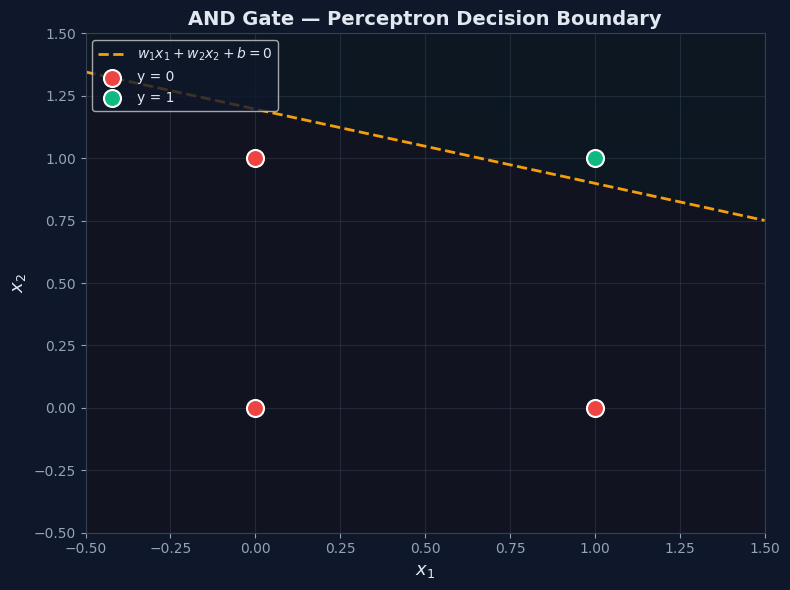

In [ ]:
def plot_decision_boundary(weights, bias, X, y, title='Decision Boundary'):
    """
    Plot the perceptron's decision boundary and colour-coded regions.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Create a mesh grid for the background
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Compute predictions for the grid
    z_grid = grid @ weights + bias
    z_pred = step_function(z_grid).reshape(xx.shape)

    # Plot coloured regions
    cmap_bg = ListedColormap(['#1a0a0a', '#0a1a0f'])
    ax.contourf(xx, yy, z_pred, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])

    # Plot decision boundary line
    if abs(weights[1]) > 1e-10:
        x_line = np.linspace(x_min, x_max, 100)
        y_line = -(weights[0] / weights[1]) * x_line - (bias / weights[1])
        ax.plot(x_line, y_line, '--', color='#F59E0B', linewidth=2,
                label=f'$w_1 x_1 + w_2 x_2 + b = 0$')

    # Plot data points
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=150, edgecolors='white',
               linewidths=1.5, zorder=5, label='y = 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=150, edgecolors='white',
               linewidths=1.5, zorder=5, label='y = 1')

    ax.set_xlabel('$x_1$', fontsize=13)
    ax.set_ylabel('$x_2$', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Plot the learned decision boundary
plot_decision_boundary(weights_final, bias_final, X, y,
                       title='AND Gate — Perceptron Decision Boundary')

**Reading the plot:** The dashed yellow line is the decision boundary $w_1 x_1 + w_2 x_2 + b = 0$. The darker region (below/left of the line) is where the perceptron predicts class 0, and the lighter region (above/right) is where it predicts class 1.

Notice that the boundary neatly separates the single green point $(1,1)$ from the three red points. There are infinitely many lines that could achieve this separation — the perceptron finds *one* of them, depending on the initial weights, learning rate, and the order of training samples.

### 5.1 Visualising Boundary Evolution Across Epochs

Let's see how the decision boundary evolves during training. Each subplot shows the boundary at a different epoch, so you can watch the line rotate and shift as the perceptron adjusts its parameters:

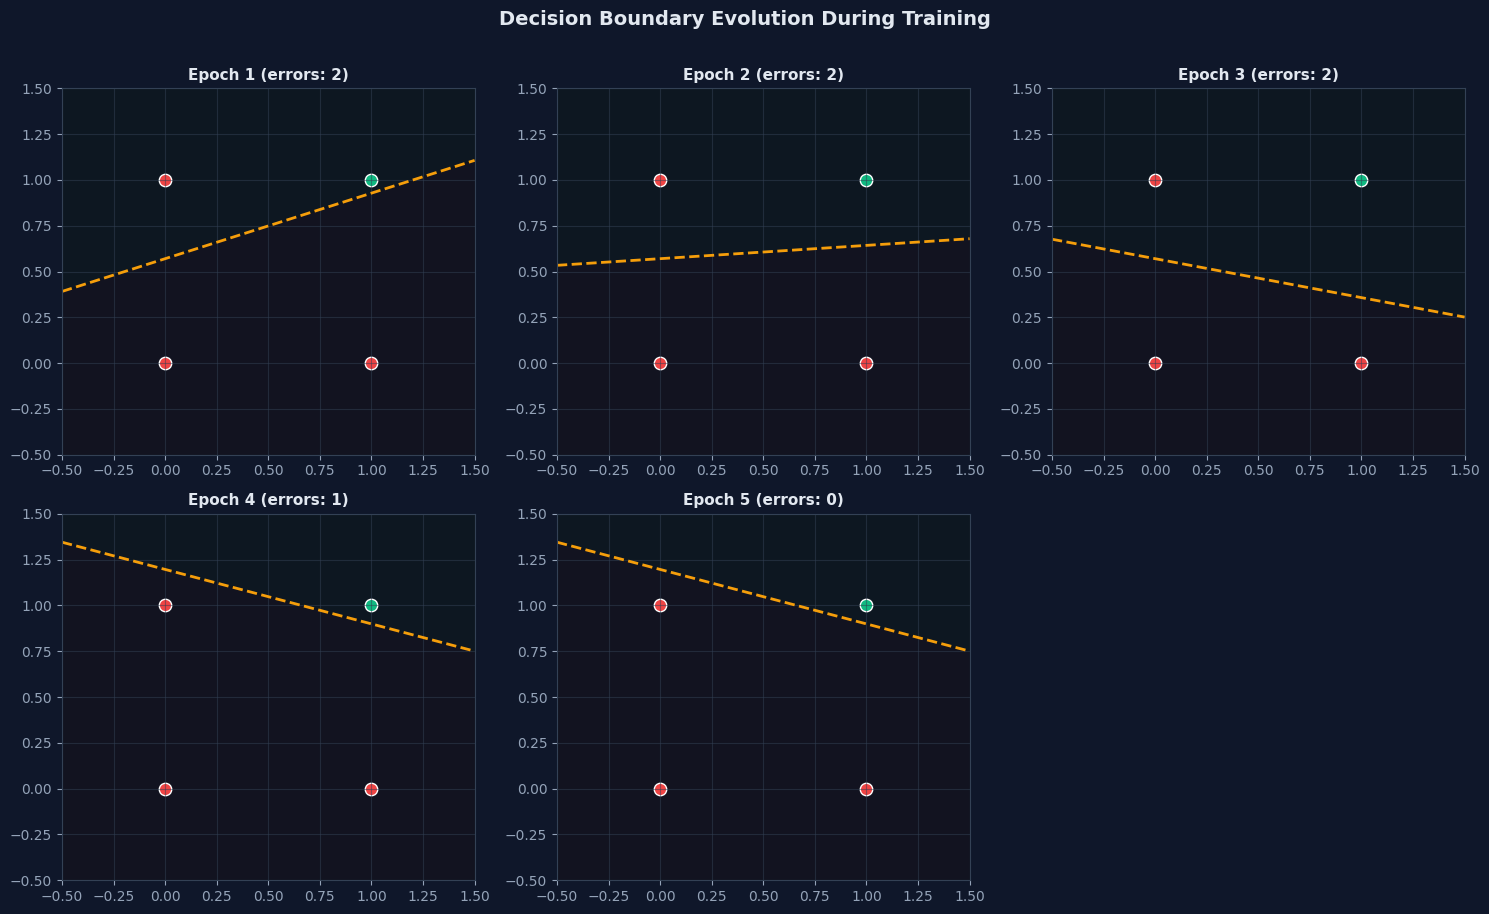

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

# Select epochs to visualise
display_epochs = [0, 1, 2, 3, min(5, len(history)-1), len(history)-1]
display_epochs = sorted(set(display_epochs))[:6]

for idx, ep_idx in enumerate(display_epochs):
    if idx >= len(axes):
        break
    ax = axes[idx]
    h = history[ep_idx]
    w, b_val = h['weights'], h['bias']

    # Mesh grid
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    z_grid = step_function(grid @ w + b_val).reshape(xx.shape)

    cmap_bg = ListedColormap(['#1a0a0a', '#0a1a0f'])
    ax.contourf(xx, yy, z_grid, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])

    if abs(w[1]) > 1e-10:
        x_line = np.linspace(-0.5, 1.5, 100)
        y_line = -(w[0] / w[1]) * x_line - (b_val / w[1])
        ax.plot(x_line, y_line, '--', color='#F59E0B', linewidth=2)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=80, edgecolors='white', linewidths=1)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=80, edgecolors='white', linewidths=1)
    ax.set_title(f'Epoch {h["epoch"]} (errors: {h["errors"]})', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True)

# Hide unused axes
for idx in range(len(display_epochs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Decision Boundary Evolution During Training', fontsize=14,
             fontweight='bold', color='#E2E8F0', y=1.01)
plt.tight_layout()
plt.show()

**Reading the subplots:** Each panel shows the state of the decision boundary at one epoch. In the early epochs the line may misclassify some points (indicated by the error count in each title). As training proceeds, the boundary rotates and shifts until all four points are on the correct side. Once the error count reaches zero, the perceptron has converged.The speed at which this happens depends on the learning rate and the initial random weights. For the AND gate with $\alpha = 0.1$, convergence is typically very fast.

### 5.2 Manual Calculation of the AND Decision Boundary

Now let's convert the learned parameters into the explicit equation of the decision line. This connects the abstract weight values to concrete geometry that you can verify on the plot above.

In [ ]:
# ============================================================# Manual Calculation of the Decision Boundary for the AND Gate# ============================================================
print("=== Decision Boundary Calculation ===\n")
w1, w2 = weights_final[0], weights_final[1]
b = bias_final
print(f"Learned parameters:")
print(f"  w1 = {w1:+.4f}")
print(f"  w2 = {w2:+.4f}")
print(f"  b  = {b:+.4f}")
print(f"\nThe decision boundary is the line where z = 0:")
print(f"  w1·x1 + w2·x2 + b = 0")
print(f"  ({w1:+.4f})·x1 + ({w2:+.4f})·x2 + ({b:+.4f}) = 0")

# Rearrange to slope-intercept form: x2 = m·x1 + c
slope = -w1/w2
intercept = -b/w2
print(f"\nRearranging for x2 (slope-intercept form):")
print(f"  x2 = -(w1/w2)·x1 - (b/w2)")
print(f"  x2 = -({w1:+.4f} / {w2:+.4f})·x1 - ({b:+.4f} / {w2:+.4f})")
print(f"  x2 = {slope:+.4f}·x1 + {intercept:+.4f}")
print(f"\n=== Geometric Interpretation ===")
print(f"  Slope     = {slope:+.4f}")
print(f"  Intercept = {intercept:+.4f}")

# Compute where the decision boundary crosses the axes
x1_intercept = -b / w1 if abs(w1) > 1e-10 else float('inf')
print(f"\nAxis crossings:")
print(f"  x2-axis (x1=0): x2 = {intercept:+.4f}")
print(f"  x1-axis (x2=0): x1 = {x1_intercept:+.4f}")

# Verify: check which side each AND gate point falls on
print(f"\n=== Verifying Each Point Against the Boundary ===")
print(f"{'Point':>10s}  {'z value':>10s}  {'Side':>12s}  {'Predicted':>10s}")
print("-" * 50)

labels_text = {0: "class 0", 1: "class 1"}
for i in range(len(X)):
  z_val = w1 * X[i][0] + w2 * X[i][1] + b
  side = "z ≥ 0 → ŷ=1" if z_val >= 0 else "z < 0 → ŷ=0"
  pred = 1 if z_val >= 0 else 0
  print(f"  ({X[i][0]:.0f}, {X[i][1]:.0f})    {z_val:+10.4f}  {side:>12s}  {labels_text[pred]:>10s}")

=== Decision Boundary Calculation ===

Learned parameters:
  w1 = +0.0745
  w2 = +0.2507
  b  = -0.3000

The decision boundary is the line where z = 0:
  w1·x1 + w2·x2 + b = 0
  (+0.0745)·x1 + (+0.2507)·x2 + (-0.3000) = 0

Rearranging for x2 (slope-intercept form):
  x2 = -(w1/w2)·x1 - (b/w2)
  x2 = -(+0.0745 / +0.2507)·x1 - (-0.3000 / +0.2507)
  x2 = -0.2973·x1 + +1.1966

=== Geometric Interpretation ===
  Slope     = -0.2973
  Intercept = +1.1966

Axis crossings:
  x2-axis (x1=0): x2 = +1.1966
  x1-axis (x2=0): x1 = +4.0247

=== Verifying Each Point Against the Boundary ===
     Point     z value          Side   Predicted
--------------------------------------------------
  (0, 0)       -0.3000   z < 0 → ŷ=0     class 0
  (0, 1)       -0.0493   z < 0 → ŷ=0     class 0
  (1, 0)       -0.2255   z < 0 → ŷ=0     class 0
  (1, 1)       +0.0253   z ≥ 0 → ŷ=1     class 1


**Output interpretation:** This cell derives the explicit equation of the learned decision boundary in the familiar form $x_2 = m \cdot x_1 + c$. The slope tells you the angle of the line, and the intercept tells you where it crosses the $x_2$-axis.

The verification table shows the signed distance $z$ of each point from the boundary. Positive $z$ means the point is on the class-1 side; negative $z$ means class-0 side. The magnitude of $z$ tells you **how confidently** the perceptron classifies that point — points far from the boundary are classified with high margin, while points close to it are borderline.

For the AND gate, the point $(1,1)$ should have the largest positive $z$, and $(0,0)$ should have the most negative $z$ (since it is furthest from needing both inputs active).

---
## 6. Training Error Over Epochs

Let's visualise how the number of misclassifications decreases over training. This is the perceptron's "learning curve" — it should drop to zero once convergence is achieved.

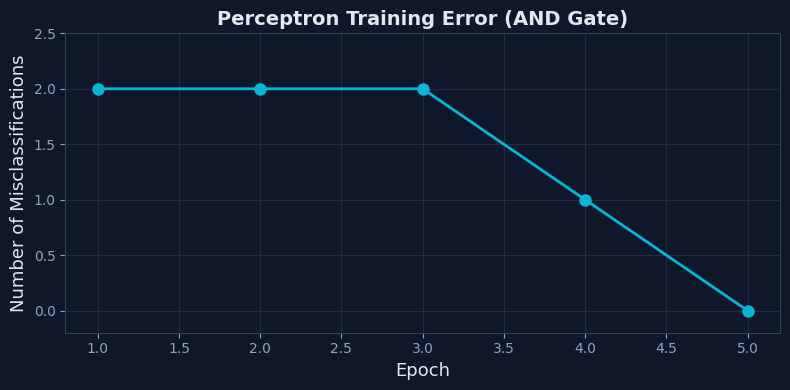

In [ ]:
epochs_list = [h['epoch'] for h in history]
errors_list = [h['errors'] for h in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_list, errors_list, 'o-', color='#06B6D4', linewidth=2, markersize=8)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Number of Misclassifications', fontsize=13)
ax.set_title('Perceptron Training Error (AND Gate)', fontsize=14, fontweight='bold')
ax.set_ylim(-0.2, max(errors_list) + 0.5)
ax.grid(True)
plt.tight_layout()
plt.show()

**Reading the plot:** Each point shows the total number of misclassifications in one epoch. A healthy training run shows this count decreasing over time and eventually reaching zero (convergence). The perceptron convergence theorem guarantees that this will happen in a finite number of steps for any linearly separable dataset.

If the curve never reaches zero, it means either the data is not linearly separable, or there is a bug in the implementation.

 ---
## 7. The XOR Problem — What the Perceptron Cannot Do

The XOR (exclusive OR) gate is **not linearly separable**. Its truth table is:

| $x_1$ | $x_2$ | XOR ($y$) |
|:-----:|:-----:|:---------:|
| 0     | 0     | 0         |
| 0     | 1     | 1         |
| 1     | 0     | 1         |
| 1     | 1     | 0         |

The positive examples $(0,1)$ and $(1,0)$ sit on opposite corners of the unit square, as do the negative examples $(0,0)$ and $(1,1)$. No single straight line can separate them. Let's verify that the perceptron fails:

Training Perceptron on XOR gate (α = 0.1):

Epoch  96: errors = 4
Epoch  97: errors = 4
Epoch  98: errors = 4
Epoch  99: errors = 4
Epoch 100: errors = 4

✗ The perceptron NEVER converged — it oscillates forever.
  Final errors per epoch: 4


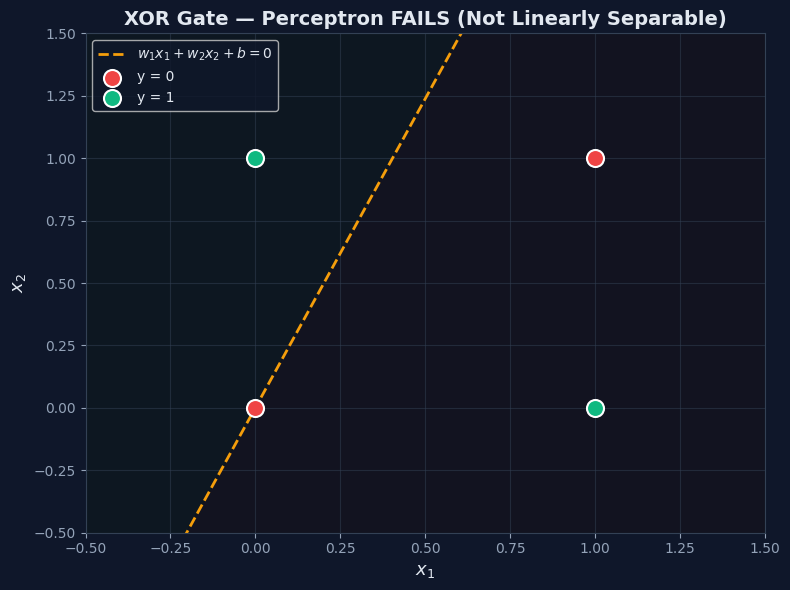

In [ ]:
# XOR gate
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

print('Training Perceptron on XOR gate (α = 0.1):\n')
w_xor, b_xor, hist_xor = train_perceptron(X_xor, y_xor, alpha=0.1, epochs=100, verbose=False)

# Show last few epochs
for h in hist_xor[-5:]:
    print(f'Epoch {h["epoch"]:3d}: errors = {h["errors"]}')

print(f'\n✗ The perceptron NEVER converged — it oscillates forever.')
print(f'  Final errors per epoch: {hist_xor[-1]["errors"]}')

# Plot the failed attempt
plot_decision_boundary(w_xor, b_xor, X_xor, y_xor,
                       title='XOR Gate — Perceptron FAILS (Not Linearly Separable)')

**Output interpretation:** The perceptron never converges — the error count oscillates without reaching zero, even after 100 epochs. The decision boundary keeps shifting back and forth because every configuration that correctly classifies one pair of points necessarily misclassifies the other pair.

As proven by Minsky & Papert (1969), no single perceptron can solve XOR because the four points cannot be separated by a single line. This is a fundamental **expressiveness limitation** of the single-layer perceptron.

**Historical significance:** This result famously contributed to the first "AI Winter" in the 1970s, as it demonstrated a clear boundary on what perceptrons could learn.

**The solution:** Overcoming this requires **multiple layers** of neurons (a multi-layer perceptron / neural network), which can learn non-linear decision boundaries. This is the subject of the ANN Architecture segment.

---
## 8. Perceptron with Gradient Descent

The classical perceptron learning rule works only with the step function and only for linearly separable problems.

**Gradient descent** provides a more general and powerful approach that:
1. Uses a **differentiable activation function** (sigmoid instead of step)
2. Minimises a **continuous loss function** (binary cross-entropy)
3. Computes **gradients** to update weights smoothlyThis section introduces the mathematical machinery that underpins all modern neural network training.

### 8.1 Sigmoid Activation

The sigmoid function is a smooth, S-shaped curve that maps any real number to the range $(0, 1)$:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Why sigmoid?** Unlike the step function, the sigmoid is differentiable everywhere. This is crucial because gradient descent requires us to compute $\frac{\partial L}{\partial w}$ — the rate of change of the loss with respect to each weight — and this derivative must exist.

Its derivative has an elegant closed form:$$\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$This means we can compute the derivative using only the output value itself — very efficient.

### 8.2 Binary Cross-Entropy Loss

We need a **loss function** that measures how wrong our predictions are. Binary cross-entropy (also called log loss) is the standard choice for binary classification:
$$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Intuition:** When $y = 1$, the loss is $-\log(\hat{y})$, which is small when $\hat{y}$ is close to 1 (correct) and very large when $\hat{y}$ is close to 0 (wrong). Similarly, when $y = 0$, the loss penalises $\hat{y}$ values close to 1. The loss is always non-negative and equals zero only for perfect predictions.

### 8.3 What Is a Gradient?

Before diving into the gradient computation, let's clarify this central concept.

**In one dimension — the derivative:** If you have a function $f(w)$ of a single variable $w$, its derivative $\frac{df}{dw}$ tells you the **rate of change**: how much $f$ changes when you make a tiny change to $w$.

Geometrically, it is the **slope of the tangent line** to the curve at that point.
- If $\frac{df}{dw} > 0$: increasing $w$ increases $f$ (the function slopes upward).
- If $\frac{df}{dw} < 0$: increasing $w$ decreases $f$ (the function slopes downward).
- If $\frac{df}{dw} = 0$: you are at a flat point — possibly a minimum, maximum, or saddle point.

**In multiple dimensions — the gradient:** When the loss $L$ depends on multiple parameters $(w_1, w_2, b)$, the **gradient** $\nabla L$ is the vector of all partial derivatives:
$$\nabla L = \left[ \frac{\partial L}{\partial w_1}, \; \frac{\partial L}{\partial w_2}, \; \frac{\partial L}{\partial b} \right]$$

Each partial derivative $\frac{\partial L}{\partial w_j}$ tells you how the loss changes if you nudge $w_j$ by a tiny amount, *while holding all other parameters fixed*.

**The gradient points "uphill":** The gradient vector points in the direction of **steepest ascent** — the direction in which the loss increases most rapidly. Therefore, to **decrease** the loss, we move in the **opposite direction**:
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \nabla L$$

This is the essence of **gradient descent**: repeatedly take small steps opposite to the gradient until you reach a minimum of the loss function.

**Analogy:** Imagine standing on a hillside in thick fog. You cannot see the valley below, but you can feel which direction the ground slopes upward under your feet. The gradient is that "slope direction". To descend, you step in the opposite direction. The learning rate $\alpha$ controls how big each step is — too large and you overshoot; too small and progress is painfully slow.

### 8.4 Gradient Computation (Chain Rule)

For a single sample, we need $\frac{\partial L}{\partial w_j}$. Using the **chain rule** of calculus, we decompose this into steps:
$$\frac{\partial L}{\partial w_j} = \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{how loss changes with prediction}} \cdot \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\text{how prediction changes with } z} \cdot \underbrace{\frac{\partial z}{\partial w_j}}_{\text{how } z \text{ changes with } w_j}$$

For cross-entropy loss combined with sigmoid activation, a remarkable simplification occurs — all the intermediate terms cancel, giving:

$$\frac{\partial L}{\partial w_j} = (\hat{y} - y) \cdot x_j$$$$\frac{\partial L}{\partial b} = (\hat{y} - y)$$

This is elegantly simple: the gradient is just the **prediction error** $(\hat{y} - y)$ multiplied by the **input** $x_j$. This simplification is one reason the sigmoid + cross-entropy pairing was historically so popular.

### 8.5 Update Rule

Applying gradient descent (stepping opposite to the gradient):

$$w_j \leftarrow w_j - \alpha \cdot \frac{\partial L}{\partial w_j} = w_j - \alpha (\hat{y} - y) x_j$$$$b \leftarrow b - \alpha (\hat{y} - y)$$

**Note the subtle difference from the perceptron rule:**

| Aspect | Perceptron Rule | Gradient Descent |
|:---|:---|:---|
| Sign convention | $w + \alpha(y - \hat{y})x$ (adds error) | $w - \alpha(\hat{y} - y)x$ (subtracts gradient) |
| Nature of $\hat{y}$ | Hard 0 or 1 (step function) | Continuous probability in $(0, 1)$ (sigmoid) |
| Magnitude of update | Always the same (error is ±1 or 0) | Proportional to confidence of error (smooth) |

Both rules push weights in the same direction when there is an error. The gradient descent version is smoother because $\hat{y}$ is continuous, producing smaller updates when the model is "almost right" and larger updates when it is "very wrong".

In [ ]:
def sigmoid(z):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    """Binary cross-entropy loss (with numerical stability)."""
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Quick test
z_test = np.array([-3, -1, 0, 1, 3])
print(f'z values:     {z_test}')
print(f'sigmoid(z):   {np.round(sigmoid(z_test), 4)}')
print(f'sigmoid(0) = {sigmoid(0):.4f}  (should be 0.5)')

z values:     [-3 -1  0  1  3]
sigmoid(z):   [0.0474 0.2689 0.5    0.7311 0.9526]
sigmoid(0) = 0.5000  (should be 0.5)


**Output interpretation:** The sigmoid function smoothly maps any input to $(0, 1)$. Note that $\sigma(0) = 0.5$ (the midpoint), large positive inputs are pushed towards 1, and large negative inputs towards 0. Unlike the step function, the transition is gradual — this smoothness is what makes gradient-based optimisation possible.

Compare with the step function from Section 4.1: where the step function had a hard jump at $z = 0$, the sigmoid has a smooth S-curve.

### 8.6 Gradient Descent Training — Manual Walkthrough

Let's trace through one complete forward and backward pass for the sample $\mathbf{x} = [1, 1]$, $y = 1$. This walkthrough shows every calculation that happens inside one training step.

In [ ]:
# Initialise
np.random.seed(42)
w_gd = np.random.uniform(-0.5, 0.5, size=2)
b_gd = 0.0
alpha_gd = 0.5

# Forward pass for x = [1, 1], y = 1
x_demo = np.array([1, 1])
y_demo = 1

z_demo = np.dot(w_gd, x_demo) + b_gd
y_hat_demo = sigmoid(z_demo)

print('=== Forward Pass ===')
print(f'Weights: w = [{w_gd[0]:.4f}, {w_gd[1]:.4f}], b = {b_gd:.4f}')
print(f'Input:   x = {x_demo}, y = {y_demo}')
print(f'z = ({w_gd[0]:.4f})(1) + ({w_gd[1]:.4f})(1) + {b_gd:.4f} = {z_demo:.4f}')
print(f'ŷ = σ({z_demo:.4f}) = 1 / (1 + e^{-z_demo:.4f}) = {y_hat_demo:.4f}')
print(f'Loss = -[{y_demo}·log({y_hat_demo:.4f}) + {1-y_demo}·log({1-y_hat_demo:.4f})]'
      f' = {binary_cross_entropy(np.array([y_demo]), np.array([y_hat_demo])):.4f}')

print(f'\n=== Backward Pass (Gradient Computation) ===')
error_gd = y_hat_demo - y_demo
print(f'Error signal: ŷ - y = {y_hat_demo:.4f} - {y_demo} = {error_gd:.4f}')
print(f'∂L/∂w1 = (ŷ - y) · x1 = {error_gd:.4f} × {x_demo[0]} = {error_gd * x_demo[0]:.4f}')
print(f'∂L/∂w2 = (ŷ - y) · x2 = {error_gd:.4f} × {x_demo[1]} = {error_gd * x_demo[1]:.4f}')
print(f'∂L/∂b  = (ŷ - y)      = {error_gd:.4f}')

print(f'\n=== Weight Update (α = {alpha_gd}) ===')
w1_new = w_gd[0] - alpha_gd * error_gd * x_demo[0]
w2_new = w_gd[1] - alpha_gd * error_gd * x_demo[1]
b_new_gd = b_gd - alpha_gd * error_gd
print(f'w1: {w_gd[0]:.4f} - {alpha_gd}×{error_gd:.4f}×{x_demo[0]} = {w1_new:.4f}')
print(f'w2: {w_gd[1]:.4f} - {alpha_gd}×{error_gd:.4f}×{x_demo[1]} = {w2_new:.4f}')
print(f'b:  {b_gd:.4f} - {alpha_gd}×{error_gd:.4f} = {b_new_gd:.4f}')

=== Forward Pass ===
Weights: w = [-0.1255, 0.4507], b = 0.0000
Input:   x = [1 1], y = 1
z = (-0.1255)(1) + (0.4507)(1) + 0.0000 = 0.3253
ŷ = σ(0.3253) = 1 / (1 + e^-0.3253) = 0.5806
Loss = -[1·log(0.5806) + 0·log(0.4194)] = 0.5437

=== Backward Pass (Gradient Computation) ===
Error signal: ŷ - y = 0.5806 - 1 = -0.4194
∂L/∂w1 = (ŷ - y) · x1 = -0.4194 × 1 = -0.4194
∂L/∂w2 = (ŷ - y) · x2 = -0.4194 × 1 = -0.4194
∂L/∂b  = (ŷ - y)      = -0.4194

=== Weight Update (α = 0.5) ===
w1: -0.1255 - 0.5×-0.4194×1 = 0.0842
w2: 0.4507 - 0.5×-0.4194×1 = 0.6604
b:  0.0000 - 0.5×-0.4194 = 0.2097


**Output interpretation — Forward Pass:** The weighted sum $z$ is computed, then passed through the sigmoid to get a probability $\hat{y}$. Since we just initialised the weights randomly, the prediction is unlikely to be close to the true label.

**Output interpretation — Backward Pass:** The error signal $(\hat{y} - y)$ tells us the direction and magnitude of the mistake. When $\hat{y} < y$ (underprediction), the error is negative, so the gradients are negative, and subtracting a negative gradient *increases* the weights — nudging the prediction upward. This is exactly what we want.

**Output interpretation — Weight Update:** Each weight is adjusted by $-\alpha \times \text{gradient}$. The learning rate $\alpha = 0.5$ is larger here than the perceptron's $\alpha = 0.1$ because gradient descent updates are inherently smoother (continuous errors rather than ±1).

### 8.7 Full Gradient Descent Training Loop

Now we train the sigmoid neuron on all four AND gate samples simultaneously using **batch gradient descent** — computing the average gradient across all samples before updating.

In [ ]:
def train_gradient_descent(X, y, alpha=0.5, epochs=200, verbose=True):
    """
    Train a single neuron using gradient descent with sigmoid activation
    and binary cross-entropy loss.
    """
    np.random.seed(42)
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, size=n_features)
    bias = 0.0
    history = []

    for epoch in range(epochs):
        # Forward pass (all samples at once)
        z = X @ weights + bias
        y_pred = sigmoid(z)

        # Compute loss
        loss = binary_cross_entropy(y, y_pred)

        # Compute gradients (averaged over all samples)
        error = y_pred - y                     # shape: (n_samples,)
        grad_w = (1 / len(y)) * (X.T @ error)  # shape: (n_features,)
        grad_b = (1 / len(y)) * np.sum(error)   # scalar

        # Update weights
        weights = weights - alpha * grad_w
        bias = bias - alpha * grad_b

        # Compute accuracy
        predictions = (y_pred >= 0.5).astype(int)
        accuracy = np.mean(predictions == y)

        history.append({
            'epoch': epoch + 1,
            'loss': loss,
            'accuracy': accuracy,
            'weights': weights.copy(),
            'bias': bias
        })

        if verbose and (epoch < 3 or epoch % 50 == 49 or epoch == epochs - 1):
            print(f'Epoch {epoch+1:4d}: loss = {loss:.4f}, accuracy = {accuracy:.0%}, '
                  f'w = [{weights[0]:+.4f}, {weights[1]:+.4f}], b = {bias:+.4f}')

    return weights, bias, history


print('Training with Gradient Descent on AND gate (α = 0.5):\n')
w_gd_final, b_gd_final, hist_gd = train_gradient_descent(X, y, alpha=0.5, epochs=300)

Training with Gradient Descent on AND gate (α = 0.5):

Epoch    1: loss = 0.7032, accuracy = 50%, w = [-0.1316, +0.4268], b = -0.1450
Epoch    2: loss = 0.6631, accuracy = 75%, w = [-0.1277, +0.4134], b = -0.2703
Epoch    3: loss = 0.6334, accuracy = 75%, w = [-0.1159, +0.4084], b = -0.3796
Epoch   50: loss = 0.3251, accuracy = 100%, w = [+1.2104, +1.3561], b = -2.2709
Epoch  100: loss = 0.2260, accuracy = 100%, w = [+2.0417, +2.0875], b = -3.3613
Epoch  150: loss = 0.1747, accuracy = 100%, w = [+2.6128, +2.6299], b = -4.1649
Epoch  200: loss = 0.1424, accuracy = 100%, w = [+3.0569, +3.0642], b = -4.8074
Epoch  250: loss = 0.1201, accuracy = 100%, w = [+3.4233, +3.4268], b = -5.3442
Epoch  300: loss = 0.1037, accuracy = 100%, w = [+3.7361, +3.7379], b = -5.8055


**Output interpretation:** Unlike the perceptron (which converges in a few epochs), gradient descent gradually reduces the loss over hundreds of epochs. The loss never reaches exactly zero because the sigmoid function can only **approach** 0 and 1, never reaching them perfectly. However, the accuracy reaches 100% once all predictions are on the correct side of the 0.5 threshold.

Watch the weights grow in magnitude as training progresses — the sigmoid neuron becomes increasingly "confident" in its predictions over time.

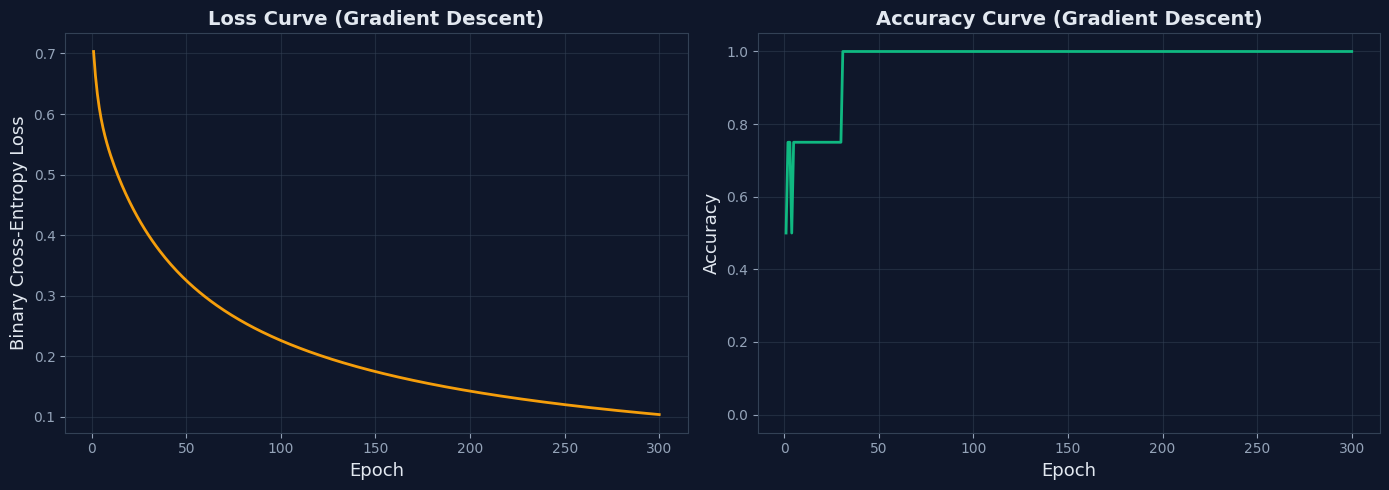

In [ ]:
# Plot loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_gd = [h['epoch'] for h in hist_gd]
losses_gd = [h['loss'] for h in hist_gd]
accs_gd = [h['accuracy'] for h in hist_gd]

ax1.plot(epochs_gd, losses_gd, color='#F59E0B', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=13)
ax1.set_title('Loss Curve (Gradient Descent)', fontsize=14, fontweight='bold')
ax1.grid(True)

ax2.plot(epochs_gd, accs_gd, color='#10B981', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_title('Accuracy Curve (Gradient Descent)', fontsize=14, fontweight='bold')
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True)

plt.tight_layout()
plt.show()

**Reading the plots:**

**Left (Loss Curve):** The binary cross-entropy loss decreases smoothly over epochs, showing that the model is steadily improving. The curve is steep early on (rapid learning) and flattens later (diminishing returns). This smooth descent is the hallmark of gradient-based optimisation — contrast this with the perceptron's abrupt jumps.

**Right (Accuracy Curve):** The accuracy jumps to 100% once all four predictions cross the 0.5 threshold. Note that accuracy is a coarse metric (it can only be 0%, 25%, 50%, 75%, or 100% with four samples), so the loss curve provides a more nuanced view of training progress.

### 8.8 Decision Boundary — Gradient Descent Version

With the sigmoid activation, the decision boundary is still $w_1 x_1 + w_2 x_2 + b = 0$ (the point where $\sigma(z) = 0.5$), but the transition is now **smooth** rather than a hard step. The colour gradient in the plot below shows the predicted probability across the input space.

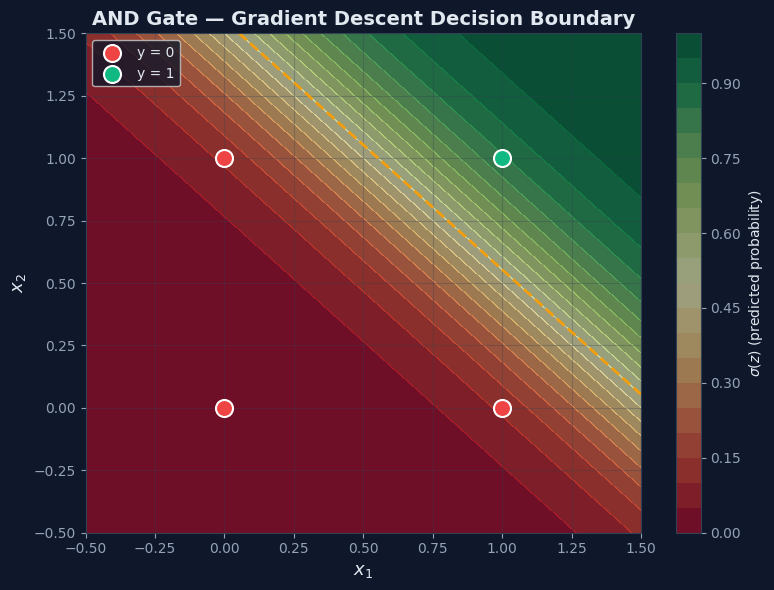

In [ ]:
def plot_decision_boundary_sigmoid(weights, bias, X, y, title='Decision Boundary (Sigmoid)'):
    """Plot the sigmoid neuron's decision boundary with probability shading."""
    fig, ax = plt.subplots(figsize=(8, 6))

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    z_grid = sigmoid(grid @ weights + bias).reshape(xx.shape)

    # Smooth probability heatmap
    im = ax.contourf(xx, yy, z_grid, levels=20, cmap='RdYlGn', alpha=0.6)
    plt.colorbar(im, ax=ax, label='$\\sigma(z)$ (predicted probability)')

    # Decision boundary (σ = 0.5)
    ax.contour(xx, yy, z_grid, levels=[0.5], colors=['#F59E0B'],
               linewidths=2, linestyles='dashed')

    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=150, edgecolors='white',
               linewidths=1.5, zorder=5, label='y = 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=150, edgecolors='white',
               linewidths=1.5, zorder=5, label='y = 1')

    ax.set_xlabel('$x_1$', fontsize=13)
    ax.set_ylabel('$x_2$', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_decision_boundary_sigmoid(w_gd_final, b_gd_final, X, y,
                                title='AND Gate — Gradient Descent Decision Boundary')

**Reading the plot:** The colour gradient shows the predicted probability $\sigma(z)$ at every point in the input space. Red regions have low probability (class 0), green regions have high probability (class 1), and yellow regions are near the decision boundary ($\sigma \approx 0.5$).

Unlike the perceptron's hard step (which has only two colours), the sigmoid creates a smooth transition. This means the model provides not just a classification, but a **confidence level** — points deep in the green region are predicted as class 1 with high confidence, while points near the yellow boundary are uncertain.

### 8.9 Verification

Let's verify the gradient descent neuron's predictions on all four AND gate inputs. Now we see both the raw $z$ value and the sigmoid probability:

In [ ]:
print(f'Final weights: w1 = {w_gd_final[0]:+.4f}, w2 = {w_gd_final[1]:+.4f}')
print(f'Final bias:    b  = {b_gd_final:+.4f}')
print()

print(f'{"x1":>4s} {"x2":>4s} {"z":>8s} {"σ(z)":>8s} {"ŷ":>4s} {"y":>4s} {"✓/✗":>4s}')
print('-' * 44)

for i in range(len(X)):
    z_val = np.dot(w_gd_final, X[i]) + b_gd_final
    prob = sigmoid(z_val)
    y_pred = 1 if prob >= 0.5 else 0
    correct = '✓' if y_pred == y[i] else '✗'
    print(f'{X[i][0]:4.0f} {X[i][1]:4.0f} {z_val:+8.4f} {prob:8.4f} {y_pred:4d} {y[i]:4d} {correct:>4s}')

Final weights: w1 = +3.7361, w2 = +3.7379
Final bias:    b  = -5.8055

  x1   x2        z     σ(z)    ŷ    y  ✓/✗
--------------------------------------------
   0    0  -5.8055   0.0030    0    0    ✓
   0    1  -2.0676   0.1123    0    0    ✓
   1    0  -2.0694   0.1121    0    0    ✓
   1    1  +1.6685   0.8414    1    1    ✓


**Output interpretation:** The $\sigma(z)$ column shows the predicted probability of class 1 for each input. For a correct classification, class-0 points should have $\sigma(z) < 0.5$ and class-1 points should have $\sigma(z) > 0.5$.

### Manual Verification:

$\mathbf{x} = [1, 1]$

Using the learned weights from the output above:
$$z = w_1 \cdot 1 + w_2 \cdot 1 + b = w_1 + w_2 + b$$$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

If $z > 0$ then $\sigma(z) > 0.5$ and the neuron predicts class 1. Check that the values in the table above confirm this. The further $z$ is from zero, the more confident the prediction — look at how the $(0,0)$ input has the most negative $z$ (most confidently class 0) and $(1,1)$ has the most positive (most confidently class 1).

---
## 9. Comparison: Perceptron Rule vs Gradient Descent

Let's compare the two approaches side by side. The left panel shows the perceptron's hard decision regions, and the right panel shows the gradient descent neuron's smooth probability landscape:

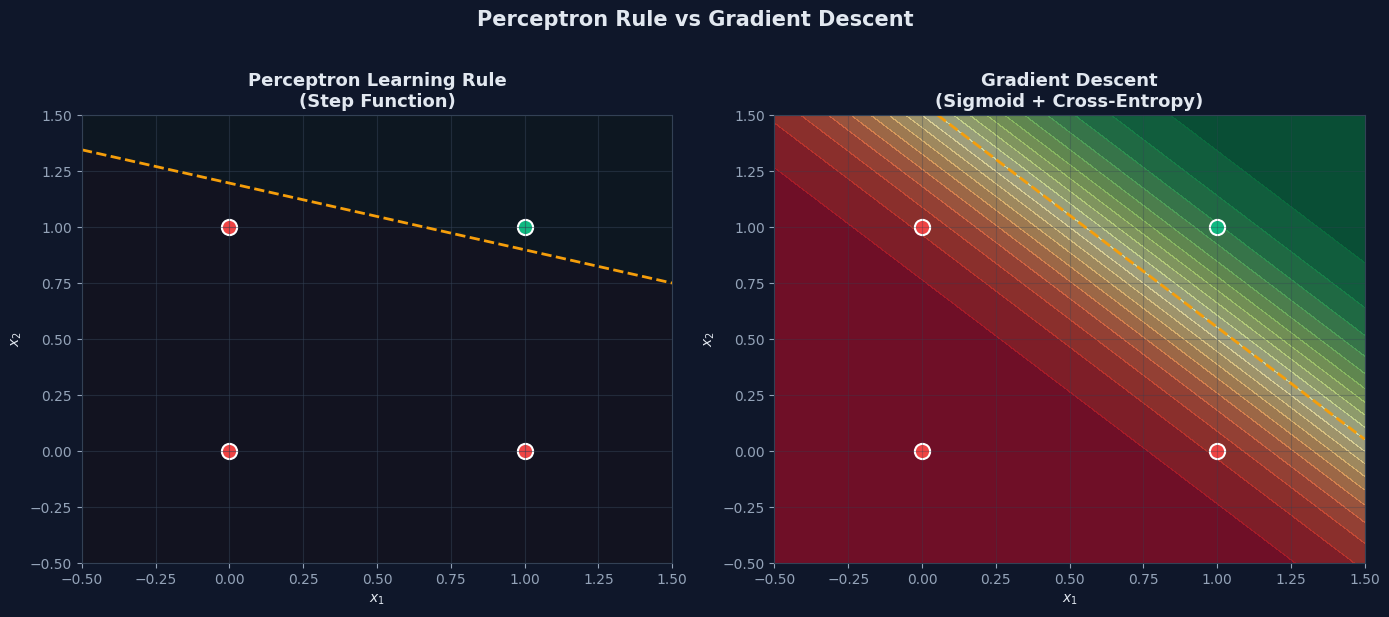

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Perceptron ---
w, b_val = weights_final, bias_final
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
z_grid = step_function(grid @ w + b_val).reshape(xx.shape)
cmap_bg = ListedColormap(['#1a0a0a', '#0a1a0f'])
ax1.contourf(xx, yy, z_grid, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])
if abs(w[1]) > 1e-10:
    x_line = np.linspace(-0.5, 1.5, 100)
    y_line = -(w[0] / w[1]) * x_line - (b_val / w[1])
    ax1.plot(x_line, y_line, '--', color='#F59E0B', linewidth=2)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=120, edgecolors='white', linewidths=1.5)
ax1.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=120, edgecolors='white', linewidths=1.5)
ax1.set_title('Perceptron Learning Rule\n(Step Function)', fontsize=13, fontweight='bold')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
ax1.set_xlim(-0.5, 1.5); ax1.set_ylim(-0.5, 1.5); ax1.grid(True)

# --- Right: Gradient Descent ---
w2, b2 = w_gd_final, b_gd_final
z_grid2 = sigmoid(grid @ w2 + b2).reshape(xx.shape)
im = ax2.contourf(xx, yy, z_grid2, levels=20, cmap='RdYlGn', alpha=0.6)
ax2.contour(xx, yy, z_grid2, levels=[0.5], colors=['#F59E0B'], linewidths=2, linestyles='dashed')
ax2.scatter(X[y == 0, 0], X[y == 0, 1], c='#EF4444', s=120, edgecolors='white', linewidths=1.5)
ax2.scatter(X[y == 1, 0], X[y == 1, 1], c='#10B981', s=120, edgecolors='white', linewidths=1.5)
ax2.set_title('Gradient Descent\n(Sigmoid + Cross-Entropy)', fontsize=13, fontweight='bold')
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')
ax2.set_xlim(-0.5, 1.5); ax2.set_ylim(-0.5, 1.5); ax2.grid(True, alpha=0.3)

plt.suptitle('Perceptron Rule vs Gradient Descent', fontsize=15,
             fontweight='bold', color='#E2E8F0', y=1.02)
plt.tight_layout()
plt.show()

**Key differences:**

| Aspect | Perceptron Rule | Gradient Descent |
|:---|:---|:---|
| Activation | Step function (hard 0/1) | Sigmoid (smooth probability) |
| Loss function | None (error-correction) | Binary cross-entropy |
| Output | Binary: 0 or 1 | Continuous: $\hat{y} \in (0, 1)$ |
| Update rule | $w \leftarrow w + \alpha \cdot e \cdot x$ | $w \leftarrow w - \alpha \cdot \nabla L$ |
| Convergence | Guaranteed for linearly separable data | Converges to minimum of loss (may be local) |
| Extends to multi-layer? | No | **Yes** — this is backpropagation |

---
## 10. Exercises

Complete the following exercises to deepen your understanding. Work through them in order.

---

### Exercise 1: OR Gate

Train the perceptron on the **OR gate**:

| $x_1$ | $x_2$ | OR |
|:-----:|:-----:|:--:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

**Tasks:**
1. Define `X_or` and `y_or`.
2. Train the perceptron using `train_perceptron()`.
3. Plot the decision boundary.
4. How many epochs does it take to converge? Compare this with the AND gate.

---

### Exercise 2: NAND Gate

The NAND gate is the negation of AND:

| $x_1$ | $x_2$ | NAND |
|:-----:|:-----:|:----:|
| 0 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

**Tasks:**
1. Train the perceptron on NAND.
2. Compare the learned weights with the AND gate. What relationship do you observe?
3. Plot both decision boundaries on the same figure.

---

### Exercise 3: Effect of Learning Rate

Train the perceptron on the AND gate with different learning rates: $\alpha \in \{0.01, 0.1, 0.5, 1.0, 5.0\}$.

**Tasks:**
1. For each $\alpha$, record the number of epochs to convergence.
2. Plot a bar chart of $\alpha$ vs. epochs to convergence.
3. What happens when $\alpha$ is very large? Does the perceptron still converge?
4. Now repeat with gradient descent. How does $\alpha$ affect the loss curve?

---

### Exercise 4: Different Activation Functions ⭐

Replace the sigmoid activation in the gradient descent version with:

**a) Tanh:**
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

Note: tanh outputs in $(-1, 1)$, so you will need to rescale your labels to $\{-1, +1\}$ or adjust the loss function.

**b) ReLU:**
$$\text{ReLU}(z) = \max(0, z)$$

Note: ReLU is not bounded, so it is not suitable for classification outputs — but you can observe what happens.

**Tasks:**
1. Implement each activation function and its derivative.
2. Train the neuron on the AND gate with each activation.
3. Plot the loss curves for all three activations on the same figure.
4. Which activation converges fastest? Which produces the most confident predictions?

---

### Exercise 5: A Larger Dataset

Generate a linearly separable dataset with 200 points using `sklearn`:

```python
from sklearn.datasets import make_classification
X_large, y_large = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
```

**Tasks:**
1. Visualise the dataset.
2. Train both the perceptron and the gradient descent neuron.
3. Compare their decision boundaries.
4. Compute the accuracy of each model.
5. What happens if the data is *not* linearly separable? (Try `flip_y=0.1` in `make_classification`.)

---

### Exercise 6: XOR with a Multi-Layer Network (Stretch)

Build a **2-layer network** (2 inputs → 2 hidden neurons → 1 output) that solves XOR.

**Hint:** You can combine two perceptrons: one that computes something like NAND and one that computes OR. The output layer combines them to produce XOR.

**Tasks:**
1. Implement forward propagation through two layers.
2. Implement backpropagation to train the network.
3. Plot the decision boundary — it should now be non-linear!
4. How many epochs does it take to converge?

In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 1: OR Gate
# ============================================================

# X_or = ...
# y_or = ...

# w_or, b_or, hist_or = train_perceptron(X_or, y_or, alpha=0.1, epochs=50)
# plot_decision_boundary(w_or, b_or, X_or, y_or, title='OR Gate')

In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 2: NAND Gate
# ============================================================


In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 3: Learning Rate Comparison
# ============================================================


In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 4: Different Activation Functions
# ============================================================

# def tanh_activation(z):
#     return np.tanh(z)

# def relu_activation(z):
#     return np.maximum(0, z)


In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 5: Larger Dataset
# ============================================================


In [ ]:
# ============================================================
# YOUR CODE HERE — Exercise 6: XOR with Multi-Layer Network
# ============================================================


---
## 11. Summary

In this notebook we have:
1. **Implemented the Perceptron Learning Algorithm** — including initialisation, forward pass, error computation, and weight updates with the step activation function.
2. **Visualised the decision boundary** and its evolution during training, and **manually calculated** the boundary equation for the AND gate.
3. **Demonstrated the XOR limitation** — confirming that a single perceptron cannot solve non-linearly separable problems (Minsky & Papert, 1969).
4. **Clarified the concept of the gradient** — the vector of partial derivatives that points uphill, and why we step in the opposite direction to minimise loss.
5. **Re-implemented the neuron using Gradient Descent** with sigmoid activation and binary cross-entropy loss, showing how the smooth loss landscape enables principled optimisation.
6. **Compared both approaches** — the perceptron rule gives hard decisions; gradient descent gives probabilities and extends to multi-layer networks via backpropagation.

### Key Equations

| Component | Perceptron Rule | Gradient Descent |
|:---|:---|:---|
| Activation | $f(z) = \begin{cases} 1 & z \geq 0 \\ 0 & z < 0 \end{cases}$ | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Loss | — (error-correction only) | $L = -\frac{1}{n}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ |
| Gradient | Not applicable (step is not differentiable) | $\nabla_w L = (\hat{y} - y) \cdot \mathbf{x}$ |
| Update | $w \leftarrow w + \alpha(y - \hat{y})x$ | $w \leftarrow w - \alpha \nabla_w L$ |

### Key Takeaways

- The **gradient** is the multi-dimensional generalisation of the slope — it tells you which direction to adjust each parameter to reduce the loss most efficiently.
- The perceptron rule is guaranteed to converge for linearly separable data but cannot extend to multi-layer networks (because the step function is not differentiable).
- Gradient descent with sigmoid activation produces smooth probability outputs and — crucially — can be generalised to networks with many layers via **backpropagation** (the chain rule applied recursively through layers). This is the foundation of deep learning.

---
*MSc Applied AI — WMG, University of Warwick — 2025/26*